# Resolução do Desafio Técnico: Análise de Feedbacks de Produto
Este projeto tem como objetivo apoiar as equipes de Produto e Experiência do Cliente na estruturação de uma solução automatizada para a análise de feedbacks enviados por usuários. A partir de comentários textuais coletados em diferentes canais, busquei construir um modelo capaz de categorizar o sentimento expresso de forma precisa, escalável e interpretável.<br>
<br>
Para a solução de projeto, optei pela avaliação de três algoritmos clássicos de aprendizado de máquina: **Naive Bayes**, **Regressão Logística** e **LinearSVC**. a minha lógica para escolher os três ML foi a seguinte:

- Devido termos poucos dados, colocar uma Rede Neural ou um modelo gigante Seria muito complexo e demorado. e teria grande chance de dar *overfitting*. Esses 3 modelos são mais simples e lidam melhor com uma base de dados pequena.
- A coluna de sentimento está balanceada com 50% positivo e 50% negativo.

A ideia é rodar os três, ver quem se sai melhor na validação e usar o campeão para gerar o arquivo final de predição do dataset.

Para manter o notebook limpo e fácil de ler, o código vai seguir essa ordem de execução:

1. **Divisão de Dados para Treinamento**
2. **Vetorização dos Textos** 
3. **Treinamento do Naive Bayes**  
4. **Treinamento da Regressão Logística**
5. **Treinamento do LinearSVC**
6. **Análise dos 3 Modelos juntos:**
7. **Análise dos 3 modelos com a base de dados de avaliação**
8. **Análise dos 3 modelos com frases complexas**
9. **escolha do modelo para predição**
10. **geração da coluna de sentimento com o modelo vencedor**
11. **Limitações no treinamento**
12. **Links Externos**
---

importação das bibliotecas e dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('data/feedback_produto_treino.csv')
df_avaliacao = pd.read_csv('data/feedback_produto_avaliacao.csv')

X = df['texto_feedback']
y = df['sentimento']

### 1. Divisão de Dados para Treinamento:

durante a escolha da divisão dos dados, iniciei esse processo utilizando o metodo **HouldOut**. porem, percebi que esse método poderia gerar problemas com dados desemquilibrados. para lidar com isso, optei por usar o método **Cross Validation**. para lidar melhor com dados desemquilibrados, tambem optei por usar o metodo **Stratifield**, que garante que a proporção original das classes sejam mantidas em cada divisão, evitando que o modelo seja treinado e validado com subgrupos tedenciosos.

In [3]:
cv = StratifiedKFold( 
    n_splits=5, # base de dados será dividida em 5  partes iguais
    shuffle=True, # embaralhamento dos dados para divisão
    random_state=42 # valor fixo para randomização 
)

### 2. Vetorização dos Textos

Durante a etapa de preparação do texto, pensei em utilizar o método de vetorização **CountVectorizer**. Porém, percebi que essa abordagem poderia gerar problemas ao dar uma importância exagerada a palavras muito frequentes, mas irrelevantes (como "o", "a", "que", "produto"), o que poderia distorcer a análise. Para lidar com isso, optei por usar o método **TF-IDF**. Diferente do modelo de contagem simples, ele garante que o peso de cada palavra seja calculado de forma proporcional à sua raridade no conjunto de dados, penalizando termos excessivamente comuns e destacando as palavras que realmente definem o sentimento e o contexto do feedback.

In [4]:
tfidf = TfidfVectorizer(
                        ngram_range=(1, 2), # com isso, coleto palavras soltas e duplas. assim posso pegar palavras separadas e juntas como "não gostei"
                        strip_accents='unicode', # remove acentos das palavras
                        lowercase=True, # trainsforma todas as palavras em minusculo
                        min_df=2 # ignora palavras que aparecem só uma vez em todo o dataset
) 

X_tfidf = tfidf.fit_transform(X) # converte os textos em matriz numerica de pesos TF-IDF

### 3. treinamento do modelo **naive bayers**(multinomialNB)

Durante a etapa de seleção do algoritmo de classificação, pensei em utilizar o **naive bayers Gaussian**, porem, percebi que esse modelo era mais adequado com valores numericos continuos, ou valores reais, como preço, peso, altura. nesse projeto, estarei lidando com frequencias de repetições de palavras, e por isso, utilizar esse modelo de naive bayers poderia gerar algum problema. para lidar com isso, optei por usar o **naive bayers Multinominal**, que lida bem melhor com vetorização TF-IDF, e com matrizes de textos.

In [5]:
nb_model = MultinomialNB() # variavel para instanciar o modelo naive bayers

y_pred_nb = cross_val_predict( # treinamento do modelo
                                nb_model, # variavel do modelo naive bayers
                                X_tfidf, # matriz de entrada
                                y,  # variavel alvo 
                                cv=cv, # aplicação da cross validation no treinamento
)

resultado do treino

RESULTADOS - NAIVE BAYES
              precision    recall  f1-score   support

    negativo       1.00      0.98      0.99        60
    positivo       0.98      1.00      0.99        60

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



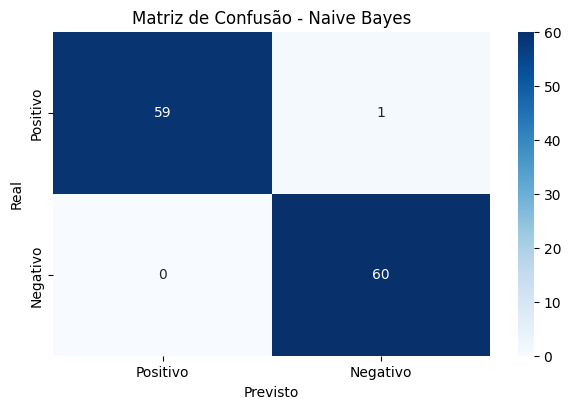

In [6]:
print("RESULTADOS - NAIVE BAYES")
print(classification_report(y, y_pred_nb)) # printa uma tabela das avaliações do modelo

cm = confusion_matrix(y, y_pred_nb) # criação da matriz de confusão

plt.figure(figsize=(6, 4)) 

sns.heatmap(  # heatmap da matriz
    cm, 
    annot=True, # mostra variaveis na celula
    fmt='d', # definiçao dos numeros em inteiros
    cmap='Blues', # cor do grafico
    xticklabels=['Positivo', 'Negativo'], 
    yticklabels=['Positivo', 'Negativo']
)

plt.title('Matriz de Confusão - Naive Bayes')
plt.tight_layout()
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

### Análise dos Resultados - Naive Bayes

O modelo inicial utilizando **Naive Bayes** apresentou um desempenho excelente na base de validação:

* **Acurácia Geral de 99%:** O modelo acertou quase todas as classificações do conjunto de validação interna.
* **F1-Score Equilibrado:** Tanto para a classe `negativo` quanto para a `positivo`, o F1-Score foi alto. Isso mostra que o modelo não está enviesado para nenhum dos lados.
* **Métricas por Classe:**
  * Para os feedbacks **Negativos**, a precisão foi de 100%, com um recall de 98%.
  * Para os feedbacks **Positivos**, o recall foi de 100%, com uma precisão de 98%.

### 4. treinamento do modelo de **Regressão Logistica**

Durante a seleção dos algoritmos, optei por utilizar a **Regressão Logística** por ser um modelo bastante eficiente para classificação de textos. uma das funções mais interessantes da **RL**, e que ela consegue estimar a probabilidade de um texto pertencer a uma determinada classe, essa função mais os vetores numericos gerados pela **TF-IDF** torna as analises mais interessantes.

In [7]:
lr_model = LogisticRegression(random_state=42) # variavel para instanciar o modelo regressão logistica. random_state para bloquear a randomização em um valor fixo

y_pred_lr = cross_val_predict( # treinamento
                                lr_model, # variavel do modelo LR
                                X_tfidf, # matriz de entrada
                                y, # variavel alvo
                                cv=cv # aplicação do cross vaidation
)

resultado do treinamento

RESULTADOS - REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

    negativo       1.00      1.00      1.00        60
    positivo       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



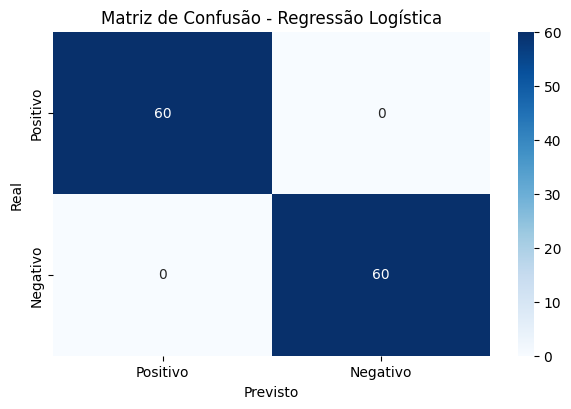

In [8]:
print("RESULTADOS - REGRESSÃO LOGÍSTICA")
print(classification_report(y, y_pred_lr)) # printa uma tabela das avaliações do modelo

cm_lr = confusion_matrix(y, y_pred_lr) # criação da matriz de confusão

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lr, # matriz confusão
    annot=True, # mostra variaveis na celula
    fmt='d', # definiçao dos numeros em inteiros
    cmap='Blues', 
    xticklabels=['Positivo', 'Negativo'], 
    yticklabels=['Positivo', 'Negativo']
)

plt.title('Matriz de Confusão - Regressão Logística')

plt.tight_layout()
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

### Análise dos Resultados - Regressão Logística

O modelo de **Regressão Logística** atingiu o desempenho máximo teórico no conjunto de validação interna:

* **Acurácia de 100%:** O algoritmo classificou corretamente todas amostras de teste, sem cometer nenhum erro.
* **Métricas Perfeitas:** Tanto a **Precisão** quanto o **Recall** cravaram 1.00 para ambas as classes.
  * Isso significa que o modelo não gerou nenhum Falso Positivo e nenhum Falso Negativo no corte de validação atual.
- **observação**: esses dados podem sinalizar um ótimo desempenho, porem, e importante notar que nesse treinamento, foi disponibilizado poucos dados, isso pode gerar problemas de overfitting.

### 5. treinamento do modelo de **LinearSVC**

Durante a seleção dos algoritmos, optei por utilizar o **LinearSVC** por ser um modelo amplamente utilizado em tarefas de classificação de textos. Esse algoritmo busca encontrar um limite de separação entre as classes, sendo especialmente eficiente em conjuntos de dados representados por vetores de alta dimensionalidade, como os gerados pelo **TF-IDF**. Além de apresentar bom desempenho em análise de sentimentos, o **LinearSVC** costuma oferecer alta precisão e lidar muito bem com grandes quantidades de atributos, tornando-se uma excelente opção para este projeto.

- **Observação:** entrego uma leve explicação sobre a implementação da calibraçaõ de platt no final do codigo

In [9]:
svc_model_base = LinearSVC(random_state=42) # variavel para instanciar o modelo linearSVC. random_state para bloquear a randomização em um valor fixo

svc_model = CalibratedClassifierCV(estimator=svc_model_base, method='sigmoid', cv=cv) # aplica a calibração de platt no LinearSVC

y_pred_svm = cross_val_predict( # treinamento
                                svc_model, # variavel do modelo
                                X_tfidf, # matriz de entrada
                                y, # variavel alvo
                                cv=cv # aplicação do cross validation
)

Resultados do Treinamento

RESULTADOS - LINEAR SVC
              precision    recall  f1-score   support

    negativo       1.00      1.00      1.00        60
    positivo       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



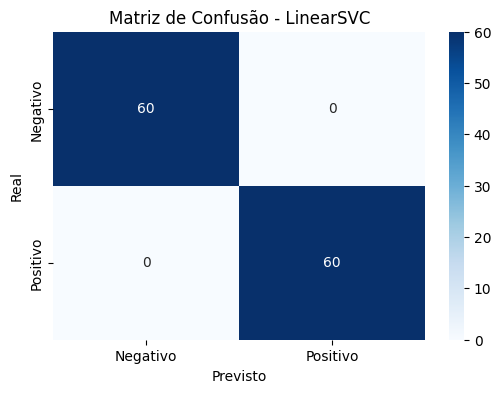

In [10]:
print("RESULTADOS - LINEAR SVC")
print(classification_report(y, y_pred_svm))  # printa uma tabela das avaliações do modelo

cm_svm = confusion_matrix(y, y_pred_svm) # criação da matriz de confusão

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_svm, # matriz confusão
    annot=True, # mostra variaveis na celula
    fmt='d', # definiçao dos numeros em inteiros
    cmap='Blues',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo']
)

plt.title('Matriz de Confusão - LinearSVC')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

## Análise dos Resultados - Linear SVC

O modelo **Linear SVC** apresentou um desempenho excepcional no conjunto de validação, alcançando resultados perfeitos em todas as métricas avaliadas.

* **Acurácia de 100%:** O modelo classificou corretamente todas as 120 amostras do conjunto de teste, sendo 60 da classe negativa e 60 da classe positiva.
* **Precisão de 100%:** Todas as previsões realizadas pelo modelo foram corretas, sem ocorrência de Falsos Positivos.
* **Recall de 100%:** O algoritmo identificou corretamente todos os exemplos de ambas as classes, sem gerar Falsos Negativos.
* **F1-Score de 100%:** O equilíbrio entre Precisão e Recall foi perfeito para as duas classes, demonstrando excelente capacidade de classificação.

**Observação:** como dito anteriormente, os resultados sairam extremamente bons, porem, isso não determina se o modelo saiu realmente bom, para conclusão final, utizarei outro dataset disponibilizado para analise de sentimento e farei uma comparação entre ambos os modelos. e como bonus, criarei umas string de textos para verificar como os modelos indicariam o sentimento de cada texto.

---

### 6. Análise dos 3 Modelos juntos:

abaixo destaco os resultados obtidos pelos modelos lado a lado junto com a matriz de confusão

In [11]:
resultados = pd.DataFrame({  # gera o dataframe dos resultados
    'Modelo': [ # coluna do nome dos modelos
        'Naive Bayes',
        'Logistic Regression',
        'Linear SVC'
    ],
    'Accuracy': [ # coluna do valor de acuracia dos modelos
        accuracy_score(y, y_pred_nb), # realiza o calculo da acuracia dos modelos
        accuracy_score(y, y_pred_lr), # y --> variavel alvo
        accuracy_score(y, y_pred_svm) # y_pred_xx --> previsões geradas pelos modelos
    ],
    'Precision': [ # coluna do valor de precisão
        precision_score(y, y_pred_nb, pos_label='positivo'), # realiza o calculo da precisão dos modelos
        precision_score(y, y_pred_lr, pos_label='positivo'),
        precision_score(y, y_pred_svm, pos_label='positivo')
    ],
    'Recall': [ # coluna do valor de recall
        recall_score(y, y_pred_nb, pos_label='positivo'), # realiza o calculo da recall dos modelos
        recall_score(y, y_pred_lr, pos_label='positivo'),
        recall_score(y, y_pred_svm, pos_label='positivo')
    ],
    'F1-Score': [ # coluna do valor de f1-Score
        f1_score(y, y_pred_nb, pos_label='positivo'), # realiza o calculo da F1 Score dos modelos
        f1_score(y, y_pred_lr, pos_label='positivo'),
        f1_score(y, y_pred_svm, pos_label='positivo')
    ]
})

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.99,0.98,1.0,0.99
1,Logistic Regression,1.00,1.00,1.0,1.00
2,Linear SVC,1.00,1.00,1.0,1.00


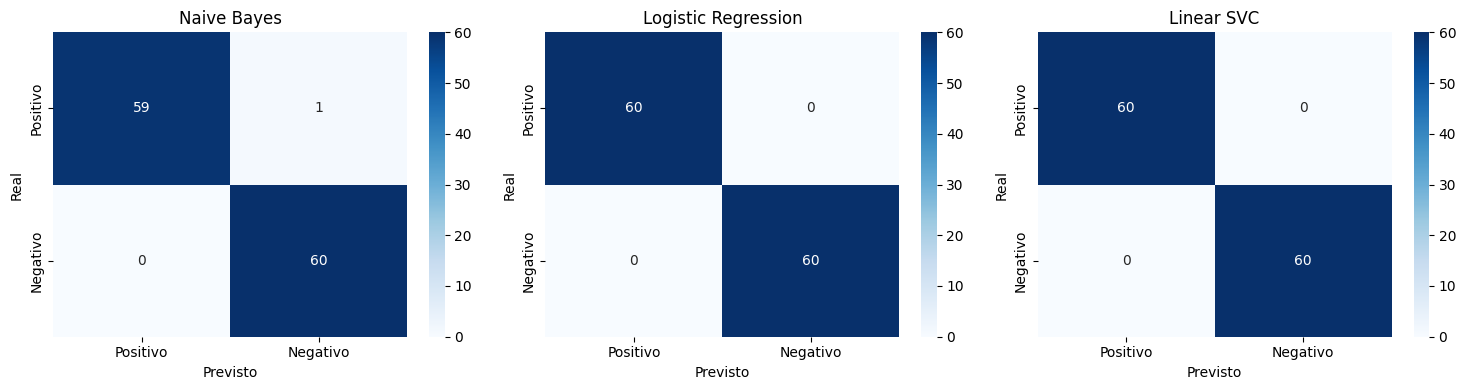

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) # gera um plot didividio em 3 imagens uma para cada modelo. gera uma lista de 3 espaços com axes

modelos = [ # lista dos modelos para geração da matriz de confusão
    ("Naive Bayes", y_pred_nb),
    ("Logistic Regression", y_pred_lr),
    ("Linear SVC", y_pred_svm)
]

for ax, (nome, pred) in zip(axes, modelos): # zip() une os elementos das duas listas, ax coleta as listas de grafico e (nome, pred) coleta o nome do modelo e a predição da lista modelo

    cm = confusion_matrix(y, pred) # criação da matriz de confusão
 
    sns.heatmap( # geração do heatmap para a matriz
        cm, # modelo da matriz
        annot=True, # mostrar os valores nas areas
        fmt='d', # colocar apenas valores inteiros
        cmap='Blues', # cor principal do grafico
        ax=ax, # pega a lista de plots
        xticklabels=['Positivo', 'Negativo'],
        yticklabels=['Positivo', 'Negativo']
    )

    ax.set_title(nome)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

display(resultados.round(2)) # utilizo a função round(2) para pegar apenas 2 casas decimais mostra o dataframe da celula anterior
plt.tight_layout()
plt.show()

Os três modelos apresentaram excelente desempenho na classificação dos sentimentos. O Naive Bayes Multinomial obteve uma acurácia de 99%, cometendo apenas um erro de classificação. Já a Regressão Logística e o LinearSVC alcançaram 100% de acurácia, precisão, recall e F1-Score, classificando corretamente todas as amostras avaliadas. Esses resultados indicam que os atributos gerados pelo TF-IDF foram capazes de representar adequadamente os textos, permitindo uma separação eficiente entre as classes positiva e negativa. Entre os modelos avaliados, Regressão Logística e LinearSVC apresentaram o melhor desempenho, empatando em todas as métricas analisadas.

Os resultados apresentados nesta etapa foram obtidos utilizando o conjunto de validação, permitindo avaliar o desempenho dos modelos em dados separados do treinamento. Embora as métricas indiquem um excelente poder de classificação, essa análise ainda está limitada aos dados disponibilizados para validação. Para uma avaliação mais próxima de um cenário real, a próxima etapa utilizará um conjunto de avaliação fornecido em um dataset separado, permitindo verificar a capacidade de generalização dos modelos em dados completamente inéditos.

---

### 7. Análise dos 3 modelos com a base de dados de avaliação

nesta analise, utilizarei o dataset `feedback_produto_avaliacao.csv` para analisar as classificação de sentimento de cada modelo. para testar lado a lado, eu progamei para que o codigo colete uma linha do dataset com o texto, ID, e os 3 modelos irão informar qual a classificação que essa linha receberá pela predição.

### **Observação:**
- durante minhas analises, ficou um pouco complexo classificar quais modelos seriam melhores, devido os valores de regressão logistica e linearCSV serem identicas. por esse motivo, decidi colocar a probabilidade de cada modelo e usar esses valores para determinar a escolha.
- infelizmente o modelo Linear SVC não trabalha com probabilidade, mas é possivel calcular a distancia dos pontos em relaçaõ a classe. para realizar algo proximo a uma probabilidade, encontrei dois métodos especificos: a calibração de Platt e regressão isotronica. ambos métodos são ótimos para converter valores de scores em probabilidade, no caso, transformar essa distancia que o modelo Linear CSV gera de um ponto a uma classe. para escolher entre os modelos, e necessario a compreensão de ambos:
    1. **calibração de platt:** ela aplica uma função sigmoid, essa funçaõ assume que o erro de calibração do modelo pode ser corrigida por uma curva suave e continua, na pratica, ela implementa um modelo de **Regressão Logistica** na saida do modelo original. alguns estudos provam que esse método e bastente eficaz quando há poucos dados disponiveis para treino e ótimo para lidar com problemas de overfitting.
    2. **regressão isotônica:** diferente do outro modelo, a regressão isotonica assume que o erro de calibração de um modelo não pode ser corrigida por uma curva mas por uma função constante por partes(algo proximo de uma escada), na teoria, um aumento no score nunca resultará na diminuição de uma probabilidade. alguns estudos afirmam que esse método tem grandes problemas de overfitting quando aplicados com uma base de dados pequena.
- após analisar ambos os modelos, percebi que o melhor método seria a calibração de platt, ao qual será utilizada para entregar uma probabilidade sobre a classificação gerada pelo modelo **LinearSVC**

- *para compreensão melhor desses métodos, anexei logo no final um artigo que explica um pouco sobre ambos métodos*

In [13]:
nb_model.fit(X_tfidf, y) # Treina o modelo Naive Bayes utilizando todos os textos vetorizados e seus respectivos rótulos
lr_model.fit(X_tfidf, y) # o mesmo para o modelo de regressão logistica
svc_model.fit(X_tfidf, y) # o mesmo para o linearSCV

CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=LinearSVC(random_state=42))

In [1]:
linha_aleatoria = df_avaliacao.sample(n=1) # seleciona aleatoriamente uma linha do dataset de avaliação
texto_aleatorio = linha_aleatoria['texto_feedback'].values[0] #retorna o texto dessa linha

texto_transformado = tfidf.transform([texto_aleatorio]) # converte o texto para TF-IDF utilizada pelo moedel

# naive bayes
prob_nb = nb_model.predict_proba(texto_transformado)[0]  # Obtém as probabilidades de positivo e negativo
idx_nb = np.argmax(prob_nb)                              # Identifica o índice da maior probabilidade
pred_nb = nb_model.classes_[idx_nb]                      # Recupera a classe correspondente à maior probabilidade
confianca_nb = prob_nb[idx_nb] * 100                     # calcula a porcentagem de confiança   

# Linear SVC (Agora com suporte a probabilidade!)
prob_svc = svc_model.predict_proba(texto_transformado)[0] # Extrai as probabilidades calibradas
idx_svm = np.argmax(prob_svc)                             # Encontra o índice da maior probabilidade
pred_svc = svc_model.classes_[idx_svm]                    # Pega a classe correspondente
confianca_svc = prob_svc[idx_svm] * 100                   # Calcula a porcentagem de confiança

# Regressão Logística
prob_lr = lr_model.predict_proba(texto_transformado)[0]   # Obtém as probabilidades calculadas pelo modelo calibrado
idx_max = np.argmax(prob_lr)                              # Encontra o índice da maior probabilidade
pred_lr = lr_model.classes_[idx_max]                      # Recupera a classe correspondente ao índice encontrado
confianca_lr = prob_lr[idx_max] * 100                     # calcula a porcentagem de confiança


print(f"Produto: {linha_aleatoria['produto'].values[0]} | ID: {linha_aleatoria['id_feedback'].values}")
print(f"Texto original: \"{texto_aleatorio}\"")
print("\n SENTIMENTO PREDITO POR CADA MODELO:")
print(f"  - Naive Bayes:         {pred_nb.upper()} (Confiança: {confianca_nb:.2f}%)")
print(f"  - Regressão Logística: {pred_lr.upper()} (Confiança: {confianca_lr:.2f}%)")
print(f"  - Linear SVC:          {pred_svc.upper()} (Confiança: {confianca_svc:.2f}%)")

NameError: name 'df_avaliacao' is not defined

- ao analisar os resultados obtidos em cada modelo,notei alguns erros de classificação no modelo Naive Bayes.
- regressão logistica e linearSVC classificaram todos os casos corretamente.
- ao aplicar a "métrica" de confiança, notei que em todos os casos o modelo SVC apresentou uma certeza maior em relação a regressão logistica.
- como ambos modelos apresentaram resultados iguais em todas analises, essa "métrica" terá um valor maior em minha analise.
- como o modelo LinearSVC utiliza uma calibração para ter uma probabilidade sobre a classificação, não posso usar esse resultado de forma 100% confiavel, pois essa calibração pode fazer o modelo gerar alto valor de confiança de forma descontrolada.
- para resolver esse possivel problema, analisarei ambos modelos com frases complexas e com um teor ironico para verificar os resultados.

### 8. Análise dos 3 modelos com frases complexas

In [15]:
frases_complexas = [
    # 1 - NEGATIVO
    "Parabéns aos envolvidos, a entrega foi incrivelmente rápida! Uma pena que o produto explodiu na primeira vez que tentei ligar na tomada.",   
    # 2 - POSITIVO 
    "Confesso que a experiência inicial com o atraso e a embalagem amassada me deixou furioso, mas o produto em si é espetacular e superou tudo.",
    # 3 - NEGATIVO
    "O design é lindo, moderno e a primeira impressão foi excelente, contudo, na prática ele simplesmente não funciona e quebrou em dois dias.",
    # 4 - POSITIVO
    "Imaginei encontrar alguma dificuldade ou complicação para configurar os menus do sistema, mas o aplicativo fluiu sem qualquer tipo de erro.",
    # 5 - NEGATIVO
    "Não posso dizer que o aparelho não cumpre o que promete, ele funciona bem, embora o preço cobrado seja exageradamente salgado.",
    # 6 - NEGATIVO
    "A compra parecia promissora no início, entretanto a embalagem chegou danificada e o suporte não conseguiu resolver meu problema adequadamente.",
    # 7 - POSITIVO
    "Depois de tantos problemas eu esperava odiar o produto, porém acabei gostando mais do que imaginava.",
    # 8 - NEGATIVO
    "Parabéns à empresa por conseguir transformar uma experiência simples em uma enorme dor de cabeça."

]

for i, frase in enumerate(frases_complexas, 1):

    frase_transformada = tfidf.transform([frase])

    # Naive Bayes
    prob_nb = nb_model.predict_proba(frase_transformada)[0]
    idx_nb = np.argmax(prob_nb)
    pred_nb = nb_model.classes_[idx_nb]
    confianca_nb = prob_nb[idx_nb] * 100

    # Linear SVC
    prob_svc = svc_model.predict_proba(frase_transformada)[0]
    idx_svm = np.argmax(prob_svc)
    pred_svc = svc_model.classes_[idx_svm]
    confianca_svc = prob_svc[idx_svm] * 100

    # Regressão Logística
    prob_lr = lr_model.predict_proba(frase_transformada)[0]
    idx_lr = np.argmax(prob_lr)
    pred_lr = lr_model.classes_[idx_lr]
    confianca_lr = prob_lr[idx_lr] * 100

    print(f"\n[Frase {i}]")
    print("-" * 95)
    print(f"Texto: \"{frase}\"")
    print("-" * 95)

    print(
        f" Naive Bayes:         "
        f"{pred_nb.upper()} "
        f"(Confiança: {confianca_nb:.2f}%)"
    )

    print(
        f" Linear SVC (SVM):    "
        f"{pred_svc.upper()} "
        f"(Confiança: {confianca_svc:.2f}%)"
    )

    print(
        f" Regressão Logística: "
        f"{pred_lr.upper()} "
        f"(Confiança: {confianca_lr:.2f}%)"
    )

    print("=" * 95)


[Frase 1]
-----------------------------------------------------------------------------------------------
Texto: "Parabéns aos envolvidos, a entrega foi incrivelmente rápida! Uma pena que o produto explodiu na primeira vez que tentei ligar na tomada."
-----------------------------------------------------------------------------------------------
 Naive Bayes:         POSITIVO (Confiança: 72.74%)
 Linear SVC (SVM):    POSITIVO (Confiança: 63.31%)
 Regressão Logística: POSITIVO (Confiança: 56.33%)

[Frase 2]
-----------------------------------------------------------------------------------------------
Texto: "Confesso que a experiência inicial com o atraso e a embalagem amassada me deixou furioso, mas o produto em si é espetacular e superou tudo."
-----------------------------------------------------------------------------------------------
 Naive Bayes:         NEGATIVO (Confiança: 64.16%)
 Linear SVC (SVM):    NEGATIVO (Confiança: 64.59%)
 Regressão Logística: NEGATIVO (Confiança: 5

##### analisando os resultados de algumas frases importantes:
* **frase 1:** essa frase e considerada falsa, todos os 3 modelos apresentaram erraram, e a confiabilidade do svc e da regressão ficaram bem proximas de 50%, demonstrando que estão incertas da resposta.
* **frase 3:** todos modelos acertaram a classificação, o SVC apresentou uma confiabilidade maior que a regressão, porem, não ficou tão distante.
* **frase 6:** a frase é negativa, e o modelo naive bayes errou, os outros dois modelos acertaram, ambos modelos apresentaram uma confiança quase identica.

nesse ultimo teste, percebi que os o modelo LinearSVC apresentou valores bem realistas de confiança, e em erros apresentando um valor proximo de 50%. isso demonstra que a calibração não esta modificando de forma descontrolada o valor.

---

### 9. **escolha do modelo para predição**

após a analise entre todos os 3 modelos, abaixo segue uma analise sobre o motivo da posição de cada modelo:<br>
##### 3. naive bayes: 
Apesar de apresentar métricas excelentes na validação cruzada (Acurácia de 99%, Precisão de 0.98, Recall de 1.00 e F1-Score de 0.99), o modelo apresentou pequenos erros de classificação ao ser testado com dados externos à base de treino, concentrados principalmente na classe positiva. Mesmo ficando em terceiro lugar neste comparativo, o Naive Bayes demonstra ser uma solução extremamente robusta, rápida e eficiente para projetos de PLN de pequeno e médio porte devido à sua simplicidade estatística.
##### 2. Regressão Logística:
O modelo atingiu a pontuação máxima (100%) em todas as métricas de validação (Acurácia, Precisão, Recall e F1-Score). O critério que o posicionou em segundo lugar foi o comportamento mais conservador em seus scores de confiança (probabilidade) em dados ambíguos. Enquanto em alguns cenários de teste o modelo classificava a classe correta com cerca de 68% de certeza, o LinearSVC se mostrava mais assertivo na mesma amostra. Apesar disso, a Regressão Logística provou ser altamente eficaz e confiável.
##### 1. LinearSVC:
O LinearSVC garantiu o primeiro lugar. Ele empatou com a Regressão Logística nas métricas macro, mas demonstrou maior firmeza e estabilidade nos níveis de confiança das classificações. É importante ressaltar uma nuance técnica: o LinearSVC não calcula probabilidades nativamente, o que exigiu a aplicação de um método de calibração probabilística (como o Platt Scaling).

---

### 10. **geração da coluna de sentimento com o modelo vencedor**

In [16]:
X_avaliacao_bruto = df_avaliacao['texto_feedback'] # coleta da coluna de texto do dataset de avaliação

X_avaliacao_tfidf = tfidf.transform(X_avaliacao_bruto) # vetorização dos textos

df_avaliacao['sentimento'] = svc_model.predict(X_avaliacao_tfidf) # predição dos textos

df_entrega = df_avaliacao[['id_feedback', 'sentimento']] # criação do dataframe que será salvo o ID e o sentimento

df_entrega.to_csv('data/feedback_final.csv', index=False) # salvamento do arquivo CSV

df_entrega.head()

,id_feedback,sentimento
0,AV018,negativo
1,AV027,negativo
2,AV026,negativo
3,AV009,positivo
4,AV029,negativo


### 11. **Limitações no treinamento**

Olhando de perto para esse desafio, consegui identificar dois pontos que limitam um pouco o resultado e que são importantes destacar:
1. **Pouco volume de dados:** Como a base de dados de treino é pequena, os modelos ficam muito dependentes das palavras exatas que estão ali. Se um cliente enviar um feedback usando gírias novas ou sinônimos que o modelo nunca viu, ele pode acabar se confundindo na hora de classificar.<br>
<br>

2. **Textos muito curtos e parecidos:** Muitos feedbacks são bem genéricos, do tipo "Muito bom", "Gostei" ou "Péssimo". Como a técnica que usei analisa o peso das palavras e não o contexto completo da frase, fica difícil para o modelo entender coisas mais profundas, como uma ironia ou quando a pessoa mistura um elogio e uma crítica na mesma frase curta.

### 12. **Links Externos**

- [Documentação do Scikit-Learn sobre Regressão Logística:](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression) Usei para entender como a Regressão Logística calcula as probabilidades de forma nativa e como ela se comporta em conjuntos de dados equilibrados.

- [Guia Prático de SVM para Iniciantes (Analytics Vidhya):](https://www.analyticsvidhya.com/blog/2021/10/support-vector-machinessvm-a-complete-guide-for-beginners/) Esse artigo foi ótimo para clarear a parte geométrica do SVM. Ele me ajudou a entender como o LinearSVC cria as margens de separação no texto, o que me deu a base para o critério de desempate contra a Regressão Logística.

- [Documentação do Scikit-Learn sobre SVM:](https://scikit-learn.org/stable/modules/svm.html) Consultei para entender as configurações específicas do LinearSVC dentro da biblioteca que estamos usando no Bootcamp, garantindo que eu estava aplicando o modelo da forma certa.

- [Artigo sobre Calibração de Probabilidade (Machine Learning Mastery):](https://machinelearningmastery.com/probability-calibration-for-imbalanced-classification/) Esse foi o mais importante para a fase final. Ele me explicou o risco do LinearSVC "surtar" com valores de confiança distorcidos após a calibração, o que me motivou a criar o teste de estresse com as frases irônicas para verificar se o modelo era mesmo confiável.